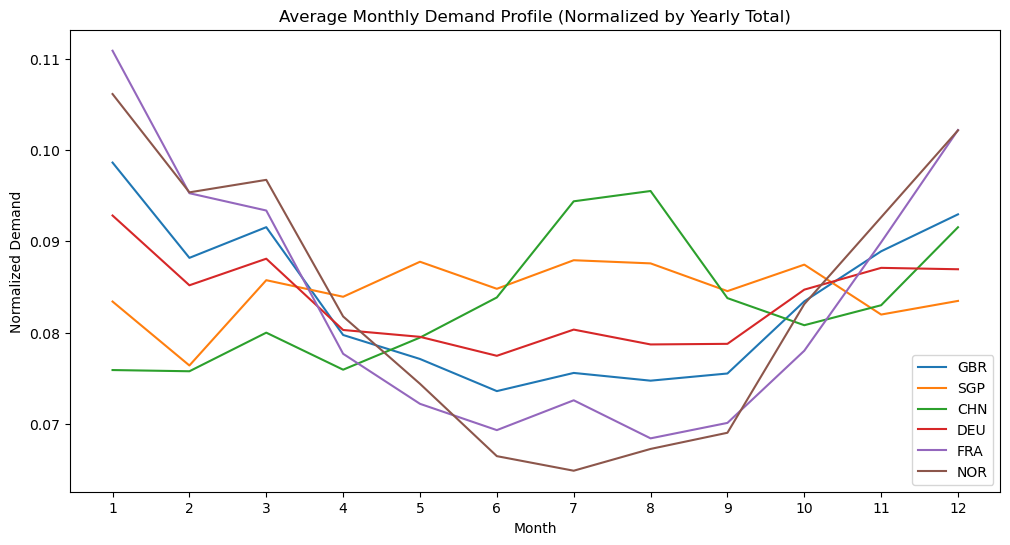

In [57]:
import pandas as pd
import matplotlib.pyplot as plt

# Load data
full_table = pd.read_csv('data/ember-countries-comparison.csv')
countries = ['GBR', 'SGP', 'CHN', 'DEU', 'FRA', 'NOR']

full_table['date'] = pd.to_datetime(full_table['date'])
full_table['year'] = full_table['date'].dt.year
full_table['month'] = full_table['date'].dt.month


monthly_profiles = {}

for country in countries:
    country_data = full_table[full_table['entity_code'] == country]
    
    
    normalized_list = []
    for year in country_data['year'].unique():
        year_data = country_data[country_data['year'] == year].copy()
        year_total = year_data['demand_twh'].sum()
        year_data['normalized'] = year_data['demand_twh'] / year_total
        normalized_list.append(year_data)
    
    normalized_df = pd.concat(normalized_list)
    
    
    monthly_avg = normalized_df.groupby('month')['normalized'].mean()
    
    monthly_profiles[country] = monthly_avg


plt.figure(figsize=(12,6))
for country, profile in monthly_profiles.items():
    plt.plot(profile.index, profile.values, label=country)

plt.xticks(range(1,13))
plt.xlabel('Month')
plt.ylabel('Normalized Demand')
plt.title('Average Monthly Demand Profile (Normalized by Yearly Total)')
plt.legend()
plt.show()




